# Giai đoạn 1 — Làm sạch phiếu khảo sát

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                              LÀM SẠCH KHẢO SÁT                              │
└─────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • data/raw/khao_sat_dinh_huong_nganh_hoc_raw.csv  —  766 phiếu × 27 cột
         │
         ▼
  XỬ LÝ
    1. Đối chiếu tên ngành với bảng chuẩn 39 ngành
    2. Phát hiện trả lời thiếu nỗ lực (IER) — ba chỉ số, loại khi vi phạm ≥ 2
    3. Loại phiếu không có môn điểm nào
    4. Gắn mã ngành và mã nhóm ngành
         │
         ▼
  ĐẦU RA
    • 01_LamSachKhaoSat/khaosat_sach.csv   —  676 phiếu
    • 01_LamSachKhaoSat/bang_ier.csv       —  ba chỉ số của TỪNG phiếu
    • 01_LamSachKhaoSat/mapping.json       —  NGUỒN CHUẨN cho 9 giai đoạn sau
    • 01_LamSachKhaoSat/bang_nganh.csv
```

## Vì sao phải loại phiếu, và loại bằng cách nào

Khảo sát là **nguồn duy nhất** để học phân phối sở thích. Giai đoạn 4 sẽ dùng phân phối
đó sinh Likert cho 15.696 hồ sơ TTTH. Nên một phiếu rác ở đây không chỉ hỏng một dòng —
nó lan sang **95,9%** dữ liệu huấn luyện cuối cùng.

### Không dùng luật tự chế

Cách cũ loại phiếu có `std(10 câu Likert) = 0`. Luật này **đúng**, nhưng không phản biện
được: hội đồng hỏi *"sao em biết họ bấm bừa mà không phải người thích mọi thứ như nhau?"*
thì không có gì để trả lời ngoài cảm tính.

Notebook này dùng quy trình chuẩn của đo lường khảo sát — **phát hiện trả lời thiếu nỗ
lực** (Insufficient Effort Responding), ba chỉ số độc lập:

| Chỉ số | Đo cái gì | Ngưỡng |
|---|---|---|
| **Longstring** | chuỗi câu trả lời giống nhau **liên tiếp** dài nhất | `≥ 10` |
| **IRV** | độ lệch chuẩn 10 câu của chính người đó | `≤ 0` |
| **Mahalanobis D²** | khoảng cách đa biến tới vector trung bình | `> χ²(10, p<.001)` |

**Loại khi vi phạm ít nhất HAI chỉ số.**

### ⚠️ Phải nói rõ: ở ngưỡng cực đại, hai chỉ số đầu là MỘT

Với thang 10 câu, `IRV = 0` ⟺ cả 10 câu giống hệt nhau ⟺ `longstring = 10`. Đây là
**đồng nhất thức**, không phải hai phép đo độc lập cùng chỉ về một chỗ. Notebook có
`assert` chứng minh hai tập trùng khít.

Vậy luật ≥2 thực chất làm đúng một việc: **chặn Mahalanobis loại phiếu một mình.** Diễn
đạt cho đúng:

> Loại phiếu điền trùng cả 10 câu. Phiếu chỉ bất thường về Mahalanobis thì **giữ lại**,
> vì bất thường đa biến không đồng nghĩa với thiếu nỗ lực — có thể chỉ là người có sở
> thích khác số đông.

Nếu muốn ba chỉ số thật sự độc lập thì phải nới ngưỡng (`longstring ≥ 8`, `IRV ≤ 0.3`),
nhưng khi đó số phiếu bị loại tăng lên 103 và ngưỡng trở thành tuỳ chọn của người làm.
Ở đây chọn ngưỡng **cực đại của thang đo** — không có tham số nào để tinh chỉnh, nên
không ai cãi được là "chọn ngưỡng cho ra kết quả đẹp".

Nguồn: Meade & Craig (2012) *Psychological Methods* 17(3) · Curran (2016) *JESP* 66 ·
Johnson (2005) *JRP* 39(1) · Dunn và cộng sự (2018) *JBP* 33(1).

### Hai bằng chứng notebook này in ra

1. **Phân bố longstring** — nếu có bậc thang ở đúng giá trị tối đa thì đó là dấu hiệu
   nhân tạo, không phải biến thể tự nhiên.
2. **Mô phỏng giả thuyết không** — rút lại 10 câu của mỗi người *độc lập* theo phân phối
   biên của từng câu, 200 lần, xem kỳ vọng có bao nhiêu phiếu điền trùng cả 10.

## `mapping.json` là nguồn chuẩn duy nhất

Chín giai đoạn sau **không được** tự khai lại bảng ngành hay bảng nhóm. Tất cả đọc từ
file này. Pipeline cũ để mỗi notebook một bản rồi trôi lệch, README ghi một đằng code
chạy một nẻo.

## Luật xuyên suốt: mọi bảng chỉ số phải có cột đoán bừa

Chín nhóm có cỡ `[7, 6, 4, 4, 4, 4, 4, 3, 3]`. Nhóm 3 ngành thì **Top-3 tự đúng 100%**
mà không cần mô hình — đoán bừa Top-3 trong nhóm đã là **69,2%**. Một con số 85% đứng
trơ trọi có thể chỉ hơn đoán bừa vài điểm. Mọi bảng đều phải đọc cột *hơn bừa*.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_NiemPhongKhaoSat",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

TEN_KHOI = {
    0: "CNTT & Máy tính",
    1: "Kinh doanh & Marketing",
    2: "Tài chính & Kế toán",
    3: "Logistics & Quản lý sản xuất",
    4: "Du lịch, Khách sạn & Ẩm thực",
    5: "Cơ khí - Điện - Tự động hoá",
    6: "Hoá - Vật liệu - Dệt may",
    7: "Thực phẩm, Sinh học & Môi trường",
    8: "Luật & Ngôn ngữ",
}

KHOI = {
    7: [   # Thực phẩm, Sinh học & Môi trường — 7 ngành
        ("Công nghệ chế biến thủy sản", 7540105),
        ("Công nghệ kỹ thuật môi trường", 7510406),
        ("Công nghệ sinh học", 7420201),
        ("Công nghệ thực phẩm", 7540101),
        ("Quản lý tài nguyên và môi trường", 7850101),
        ("Quản trị kinh doanh thực phẩm", 7340129),
        ("Đảm bảo chất lượng và an toàn thực phẩm", 7540106),
    ],
    4: [   # Du lịch, Khách sạn & Ẩm thực — 6 ngành
        ("Du lịch", 7810101),
        ("Khoa học chế biến món ăn", 7819010),
        ("Khoa học dinh dưỡng và ẩm thực", 7819009),
        ("Quản trị dịch vụ du lịch và lữ hành", 7810103),
        ("Quản trị khách sạn", 7810201),
        ("Quản trị nhà hàng và dịch vụ ăn uống", 7810202),
    ],
    0: [   # CNTT & Máy tính — 4 ngành
        ("An toàn thông tin", 7480202),
        ("Công nghệ thông tin", 7480201),
        ("Khoa học dữ liệu", 7460108),
        ("Trí tuệ nhân tạo", 7480107),
    ],
    1: [   # Kinh doanh & Marketing — 4 ngành
        ("Kinh doanh quốc tế", 7340120),
        ("Marketing", 7340115),
        ("Quản trị kinh doanh", 7340101),
        ("Thương mại điện tử", 7340122),
    ],
    5: [   # Cơ khí - Điện - Tự động hoá — 4 ngành
        ("Công nghệ chế tạo máy", 7510202),
        ("Công nghệ kỹ thuật cơ điện tử", 7510203),
        ("Công nghệ kỹ thuật điều khiển và TĐH", 7510303),
        ("Công nghệ kỹ thuật điện - điện tử", 7510301),
    ],
    6: [   # Hoá - Vật liệu - Dệt may — 4 ngành
        ("Công nghệ dệt, may", 7540204),
        ("Công nghệ kỹ thuật hóa học", 7510401),
        ("Công nghệ vật liệu", 7510402),
        ("Kỹ thuật nhiệt", 7520115),
    ],
    8: [   # Luật & Ngôn ngữ — 4 ngành
        ("Luật", 7380101),
        ("Luật kinh tế", 7380107),
        ("Ngôn ngữ Anh", 7220201),
        ("Ngôn ngữ Trung Quốc", 7220204),
    ],
    2: [   # Tài chính & Kế toán — 3 ngành
        ("Công nghệ tài chính", 7340205),
        ("Kế toán", 7340301),
        ("Tài chính ngân hàng", 7340201),
    ],
    3: [   # Logistics & Quản lý sản xuất — 3 ngành
        ("Kinh doanh thời trang và dệt may", 7340123),
        ("Logistics và quản lý chuỗi cung ứng", 7510605),
        ("Quản lý Công nghiệp", 7510601),
    ],
}

from scipy.stats import chi2

OUT = thu_muc(1)
tho = pd.read_csv(RAW / "khao_sat_dinh_huong_nganh_hoc_raw.csv")

TEN_TO_MA = {t: m for ds in KHOI.values() for t, m in ds}
MA_TO_TEN = {m: t for t, m in TEN_TO_MA.items()}
NGANH_TO_KHOI = {m: k for k, ds in KHOI.items() for _, m in ds}
L = [c for c in tho.columns if c.startswith("likert_")]
C_DIEM = [c for c in tho.columns if c.startswith("diem_")]

assert len(TEN_TO_MA) == 39, f"phải đủ 39 ngành, đang có {len(TEN_TO_MA)}"
print(f"Đọc      : {len(tho)} phiếu · {len(tho.columns)} cột")
print(f"Taxonomy : {len(TEN_TO_MA)} ngành → {len(KHOI)} nhóm")
print(f"Cỡ nhóm  : {sorted((len(v) for v in KHOI.values()), reverse=True)}")
print(f"Likert   : {len(L)} câu · Điểm: {len(C_DIEM)} môn")

Đọc      : 766 phiếu · 27 cột
Taxonomy : 39 ngành → 9 nhóm
Cỡ nhóm  : [7, 6, 4, 4, 4, 4, 4, 3, 3]
Likert   : 10 câu · Điểm: 10 môn


## 1. Ba chỉ số phát hiện trả lời thiếu nỗ lực

In [2]:
X = tho[L].to_numpy(float)
n, k = X.shape


def longstring(hang):
    """Chuỗi câu trả lời giống nhau LIÊN TIẾP dài nhất.

    Khác IRV ở chỗ nó quan tâm THỨ TỰ: người bấm 5,1,5,1,5,1,5,1,5,1 có IRV cao
    (trông như phân biệt tốt) nhưng longstring chỉ 1 — còn người bấm
    1,1,1,1,1,5,5,5,5,5 thì IRV cũng cao mà longstring tới 5.
    """
    dai = mx = 1
    for i in range(1, len(hang)):
        dai = dai + 1 if hang[i] == hang[i - 1] else 1
        mx = max(mx, dai)
    return mx


ls = np.array([longstring(h) for h in X])          # ① Longstring
irv = X.std(axis=1, ddof=0)                        # ② Intra-individual Response Variability

# ③ Mahalanobis D² — có tính tới TƯƠNG QUAN giữa các câu, nên bắt được mẫu trả
#    lời bất thường mà hai chỉ số trên bỏ sót. Dùng pinv vì ma trận hiệp phương
#    sai có thể suy biến khi vài câu gần như trùng nhau.
mu = X.mean(axis=0)
Sinv = np.linalg.pinv(np.cov(X, rowvar=False))
hieu = X - mu
md2 = np.einsum("ij,jk,ik->i", hieu, Sinv, hieu)
NGUONG_MD = chi2.ppf(0.999, df=k)

vi_pham = (ls >= 10).astype(int) + (irv <= 0).astype(int) + (md2 > NGUONG_MD).astype(int)

print(f"① Longstring ≥ 10           : {int((ls >= 10).sum()):3d} phiếu")
print(f"② IRV ≤ 0                   : {int((irv <= 0).sum()):3d} phiếu")
print(f"③ Mahalanobis D² > {NGUONG_MD:5.2f}   : {int((md2 > NGUONG_MD).sum()):3d} phiếu")

# Ở ngưỡng cực đại, ① và ② là ĐỒNG NHẤT THỨC chứ không phải hai phép đo độc
# lập: IRV = 0 ⟺ cả 10 câu giống nhau ⟺ longstring = 10. Nói "hai chỉ số độc
# lập cùng chỉ về một tập" là overclaim — chứng minh luôn ở đây cho minh bạch.
assert set(np.where(ls >= 10)[0]) == set(np.where(irv <= 0)[0]), "phải trùng khít"
print("   ⚠️  ① và ② trùng khít (đồng nhất thức với thang 10 câu), KHÔNG độc lập")
print("       → luật ≥2 thực chất chỉ để CHẶN ③ loại phiếu một mình")
print()
for v in (3, 2, 1, 0):
    print(f"   vi phạm {v} chỉ số : {int((vi_pham == v).sum()):3d} phiếu"
          + ("   ← LOẠI" if v >= 2 else ""))
print(f"\n→ Loại {int((vi_pham >= 2).sum())} phiếu, còn {int((vi_pham < 2).sum())}")

① Longstring ≥ 10           :  90 phiếu
② IRV ≤ 0                   :  90 phiếu
③ Mahalanobis D² > 29.59   :  11 phiếu
   ⚠️  ① và ② trùng khít (đồng nhất thức với thang 10 câu), KHÔNG độc lập
       → luật ≥2 thực chất chỉ để CHẶN ③ loại phiếu một mình

   vi phạm 3 chỉ số :   0 phiếu   ← LOẠI
   vi phạm 2 chỉ số :  90 phiếu   ← LOẠI
   vi phạm 1 chỉ số :  11 phiếu
   vi phạm 0 chỉ số : 665 phiếu

→ Loại 90 phiếu, còn 676


   💾 hinh_1_1_longstring


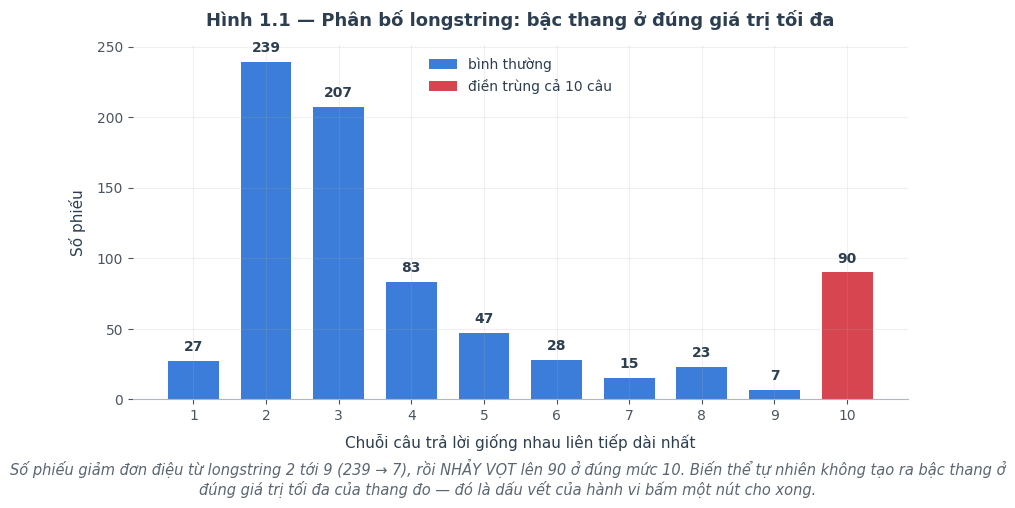

In [3]:
# ═══════════ HÌNH 1.1 — Phân bố longstring ═══════════
# Đây là bằng chứng thứ nhất: phân bố tự nhiên giảm đều, không có bậc thang.
fig, ax = plt.subplots(figsize=(10, 4.6))
gt, sl = np.unique(ls, return_counts=True)
mau = [C_THAT if g >= 10 else C_XANH for g in gt]
ax.bar(gt, sl, color=mau, width=.7)
nhan_doc(ax)
ax.set_xlabel("Chuỗi câu trả lời giống nhau liên tiếp dài nhất")
ax.set_ylabel("Số phiếu")
ax.set_xticks(gt)
ax.set_title("Hình 1.1 — Phân bố longstring: bậc thang ở đúng giá trị tối đa")
ax.legend(handles=[Patch(facecolor=C_XANH, label="bình thường"),
                   Patch(facecolor=C_THAT, label="điền trùng cả 10 câu")], loc="upper center")
n10 = int(sl[gt == 10][0]) if (gt == 10).any() else 0
n9 = int(sl[gt == 9][0]) if (gt == 9).any() else 0
luu(fig, OUT, "hinh_1_1_longstring",
    f"Số phiếu giảm đơn điệu từ longstring 2 tới 9 ({int(sl[gt==2][0])} → {n9}), rồi "
    f"NHẢY VỌT lên {n10} ở đúng mức 10. Biến thể tự nhiên không tạo ra bậc thang ở "
    f"đúng giá trị tối đa của thang đo — đó là dấu vết của hành vi bấm một nút cho xong.")

In [4]:
# ═══════════ Bằng chứng 2 — mô phỏng giả thuyết không ═══════════
# Rút lại 10 câu của mỗi người ĐỘC LẬP theo phân phối biên của TỪNG câu: giữ
# nguyên độ khó của mỗi câu, chỉ bỏ đi tính nhất quán trong một người. Nếu
# longstring = 10 xuất hiện nhiều dưới giả thuyết này thì nó là ngẫu nhiên.
rng = np.random.default_rng(SEED)
dem = np.array([
    (np.array([longstring(h) for h in
               np.column_stack([rng.choice(X[:, j], n) for j in range(k)])]) == 10).sum()
    for _ in range(200)
])

print(f"Số phiếu điền trùng cả 10 câu")
print(f"   mô phỏng null (200 lần) : trung bình {dem.mean():.1f} · khoảng {dem.min()}–{dem.max()}")
print(f"   QUAN SÁT THẬT           : {int((ls >= 10).sum())}")
print(f"\n→ Dưới giả thuyết 10 câu độc lập, gần như không thể có ngần ấy phiếu trùng.")

Số phiếu điền trùng cả 10 câu
   mô phỏng null (200 lần) : trung bình 0.0 · khoảng 0–1
   QUAN SÁT THẬT           : 90

→ Dưới giả thuyết 10 câu độc lập, gần như không thể có ngần ấy phiếu trùng.


## 2. Phễu lọc

In [5]:
buoc = [("Phiếu thu được", len(tho))]
d = tho.copy()
d["ier_longstring"], d["ier_irv"], d["ier_mahalanobis"] = ls, irv, md2
d["ier_so_vi_pham"] = vi_pham

# ── Bước 1: tên ngành phải khớp bảng chuẩn ────────────────────────────────
d["nganh_hoc"] = d.nganh_hoc.astype(str).str.strip()
la = d.nganh_hoc.isin(TEN_TO_MA)
if (~la).any():
    print("Tên ngành không khớp bảng chuẩn:")
    for t, c in d.loc[~la, "nganh_hoc"].value_counts().items():
        print(f"   {c:3d} phiếu · {t!r}")
d = d[la].copy()
buoc.append(("Ngành khớp bảng chuẩn", len(d)))

# ── Bước 2: loại theo quy trình IER ───────────────────────────────────────
loai = d.ier_so_vi_pham >= 2
print(f"\nPhiếu vi phạm ≥ 2 chỉ số IER: {int(loai.sum())}")
if loai.any():
    print("   mức hay chọn nhất:", d.loc[loai, L[0]].value_counts().head(3).to_dict())
giu1 = d.ier_so_vi_pham == 1
print(f"Phiếu chỉ vi phạm 1 chỉ số (GIỮ LẠI): {int(giu1.sum())}")
for _, r in d[giu1].head(3).iterrows():
    print("   " + " ".join(f"{int(v)}" for v in r[L]) + f"   IRV={r.ier_irv:.2f}")
d = d[~loai].copy()
buoc.append(("Bỏ phiếu thiếu nỗ lực (IER)", len(d)))

# ── Bước 3: phải có ít nhất một môn điểm ──────────────────────────────────
d = d[d[C_DIEM].notna().sum(axis=1) > 0].copy()
buoc.append(("Có ít nhất 1 môn điểm", len(d)))

d["likert_dolech"] = d[L].astype(float).std(axis=1)
d["ma_nganh"] = d.nganh_hoc.map(TEN_TO_MA)
d["ma_khoi"] = d.ma_nganh.map(NGANH_TO_KHOI)
d = d.reset_index(drop=True)

print()
for i, (ten, sl_) in enumerate(buoc):
    mat = f"  (−{buoc[i-1][1]-sl_})" if i else ""
    print(f"   {ten:<30} {sl_:>4}{mat}")
print(f"\nCòn lại {len(d)} phiếu · {d.ma_nganh.nunique()}/39 ngành"
      f" · {d.ma_khoi.nunique()}/{len(KHOI)} nhóm")
assert d.ma_nganh.nunique() == 39, "có ngành không còn phiếu nào"
assert d.likert_dolech.min() > 0, "còn sót phiếu độ lệch 0 — công thức ips sẽ hỏng"


Phiếu vi phạm ≥ 2 chỉ số IER: 90
   mức hay chọn nhất: {5: 50, 3: 24, 1: 7}
Phiếu chỉ vi phạm 1 chỉ số (GIỮ LẠI): 11
   2 1 5 5 5 1 1 1 5 1   IRV=1.90
   1 3 1 1 1 1 4 4 5 2   IRV=1.49
   2 5 3 1 5 1 5 3 4 3   IRV=1.47

   Phiếu thu được                  766
   Ngành khớp bảng chuẩn           766  (−0)
   Bỏ phiếu thiếu nỗ lực (IER)     676  (−90)
   Có ít nhất 1 môn điểm           676  (−0)

Còn lại 676 phiếu · 39/39 ngành · 9/9 nhóm


   💾 hinh_1_2_pheu_loc


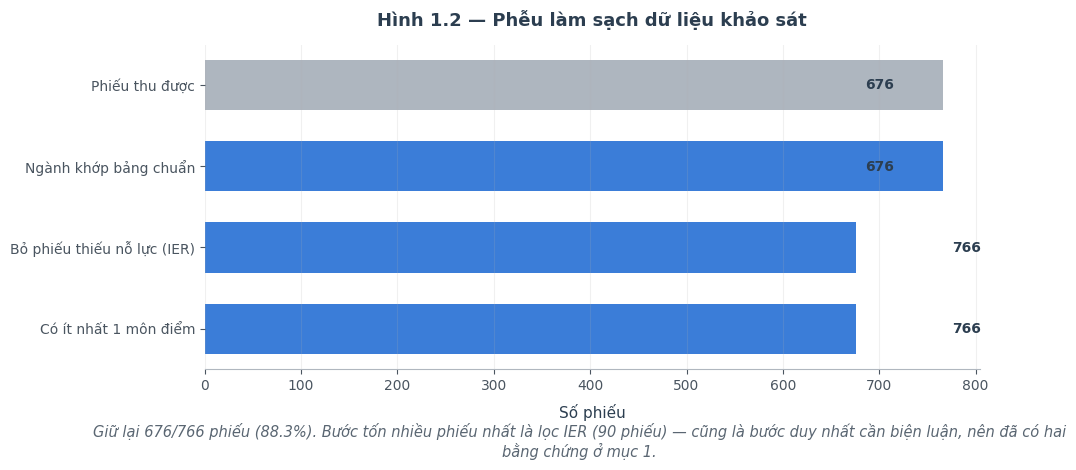

In [6]:
# ═══════════ HÌNH 1.2 — Phễu lọc ═══════════
fig, ax = plt.subplots(figsize=(10, 4.2))
ten = [b[0] for b in buoc]; sl_ = [b[1] for b in buoc]
ax.barh(range(len(buoc))[::-1], sl_, color=[C_XAM] + [C_XANH] * (len(buoc) - 1), height=.62)
ax.set_yticks(range(len(buoc))[::-1]); ax.set_yticklabels(ten, fontsize=10)
ax.set_xlabel("Số phiếu"); ax.grid(axis="y", alpha=0)
ax.set_title("Hình 1.2 — Phễu làm sạch dữ liệu khảo sát")
nhan_ngang(ax, sl_)
luu(fig, OUT, "hinh_1_2_pheu_loc",
    f"Giữ lại {sl_[-1]}/{sl_[0]} phiếu ({100*sl_[-1]/sl_[0]:.1f}%). Bước tốn nhiều phiếu "
    f"nhất là lọc IER ({buoc[1][1]-buoc[2][1]} phiếu) — cũng là bước duy nhất cần biện "
    f"luận, nên đã có hai bằng chứng ở mục 1.")

## 3. Ghi kết quả

In [7]:
d.to_csv(OUT / "khaosat_sach.csv", index=False)

# Bảng IER của TỪNG phiếu — để tra ngược được mọi câu hỏi "sao loại phiếu đó".
pd.DataFrame({
    "nganh_hoc": tho.nganh_hoc,
    "longstring": ls, "irv": irv, "mahalanobis_d2": md2,
    "vuot_longstring": (ls >= 10).astype(int),
    "vuot_irv": (irv <= 0).astype(int),
    "vuot_mahalanobis": (md2 > NGUONG_MD).astype(int),
    "so_vi_pham": vi_pham,
    "bi_loai": (vi_pham >= 2).astype(int),
}).to_csv(OUT / "bang_ier.csv", index=False)

# Chín giai đoạn sau đọc file này. Đổi tên khoá là phải vá cả chín notebook,
# nên lược đồ dưới đây coi như hợp đồng, không sửa tuỳ tiện.
mapping = {
    "ten_cach_nhom": "nhóm ngành (chia lại từ 7 khối gốc của HUIT)",
    "ten_to_ma": TEN_TO_MA,
    "ma_to_ten": {str(m): t for m, t in MA_TO_TEN.items()},
    "nganh_to_nhom": {str(m): k for m, k in NGANH_TO_KHOI.items()},
    "ten_nhom": {str(k): v for k, v in TEN_KHOI.items()},
    "nhom_chi_tiet": {str(k): [t for t, _ in v] for k, v in KHOI.items()},
    "cot_likert": L,
    "cot_diem": C_DIEM,
    "n_sach": len(d),
    "nguong_ier": {"longstring": 10, "irv": 0.0, "mahalanobis_d2": float(NGUONG_MD),
                   "so_chi_so_toi_thieu": 2},
    "ghi_chu": "Nguồn chuẩn duy nhất cho toàn pipeline.",
}
(OUT / "mapping.json").write_text(
    json.dumps(mapping, ensure_ascii=False, indent=2), encoding="utf-8")

pd.DataFrame([{"ma_nganh": m, "nganh_hoc": MA_TO_TEN[m],
               "ma_khoi": NGANH_TO_KHOI[m], "ten_khoi": TEN_KHOI[NGANH_TO_KHOI[m]],
               "so_phieu": int((d.ma_nganh == m).sum())}
              for m in sorted(MA_TO_TEN)]).to_csv(OUT / "bang_nganh.csv", index=False)

tom_tat("GIAI ĐOẠN 1 — LÀM SẠCH KHẢO SÁT", [
    f"Phiếu thu được         {len(tho)}",
    f"Loại theo IER (≥2/3)   {int((vi_pham >= 2).sum())}",
    f"Giữ lại                {len(d)}",
    f"Ngành / nhóm           {d.ma_nganh.nunique()} / {d.ma_khoi.nunique()}",
    f"Ngành ít phiếu nhất    {int(d.ma_nganh.value_counts().min())} phiếu",
    f"Đặc trưng gốc          {len(L)} câu Likert · {len(C_DIEM)} môn điểm",
])
print(f"\n✅ khaosat_sach.csv · bang_ier.csv · mapping.json · bang_nganh.csv  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                      GIAI ĐOẠN 1 — LÀM SẠCH KHẢO SÁT                       ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Phiếu thu được         766                                                 ║
║ Loại theo IER (≥2/3)   90                                                  ║
║ Giữ lại                676                                                 ║
║ Ngành / nhóm           39 / 9                                              ║
║ Ngành ít phiếu nhất    6 phiếu                                             ║
║ Đặc trưng gốc          10 câu Likert · 10 môn điểm                         ║
╚════════════════════════════════════════════════════════════════════════════╝

✅ khaosat_sach.csv · bang_ier.csv · mapping.json · bang_nganh.csv  →  ../data/processed/01_LamSachKhaoSat
